# Home Credit Default Risk Analysis
## Business Problem
> ### Can we predict whether an applicant will experience payment difficulties based on information available at the time of application? 

In [3]:
# Let's inspect the data
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('../data/raw/credit_default_data/application_train.csv')

In [5]:
df.shape

(307511, 122)

In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [8]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [10]:
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [11]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Target VS Features
----------------------
#### Our machine learning formulation is
#### $X -> y$
#### Where X is the feature matrix (total_income, credit_amt, birth_date,...)
#### y is our target

In [12]:
# Let's inspect the columns systematically
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [13]:
# let's get the categorical columns
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols.tolist()

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/525559232.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [14]:
len(categorical_cols)

16

In [15]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

len(numerical_cols)

106

In [16]:
# Now let's inspect the categorical variables
for col in categorical_cols:
    #print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower seconda

In [17]:
df.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [18]:
# let's quantify missing data
missing  = (df.isna().sum().to_frame("missing_count"))
missing

,missing_count
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [19]:
missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
)

In [20]:
missing = (
    missing[missing["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

In [21]:
missing.head(20)

,missing_count,missing_percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953


In [22]:
# duplicate applications
df["SK_ID_CURR"].duplicated().sum()

np.int64(0)

In [23]:
# complete duplicate rows
df.duplicated().sum()

np.int64(0)

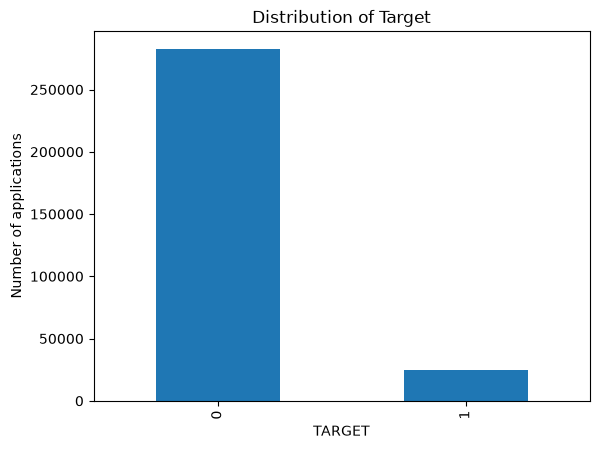

In [24]:
# Let's visualize the target
import matplotlib.pyplot as plt

df["TARGET"].value_counts().plot(kind="bar")

plt.xlabel("TARGET")
plt.ylabel("Number of applications")
plt.title("Distribution of Target")
plt.show()

In [25]:
# Let's see the missing data more clearly
missing["missing_percent"].describe()

count    67.000000
mean     44.422461
std      24.092191
min       0.000325
25%      25.585426
50%      50.749729
75%      62.683774
max      69.872297
Name: missing_percent, dtype: float64

In [26]:
# how many columns have more than 50% missing values
missing[missing["missing_percent"] > 50].shape

(41, 2)

In [27]:
missing[missing["missing_percent"] > 30].shape

(50, 2)

In [28]:
missing[missing["missing_percent"] == 0].shape

(0, 2)

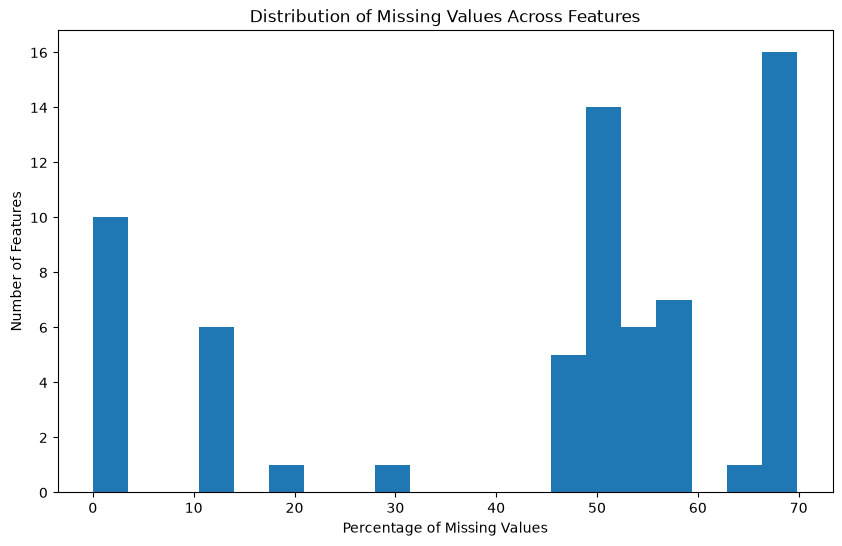

In [29]:
# let's see complete missing distribution
plt.figure(figsize=(10, 6))

plt.hist(
    missing["missing_percent"],
    bins=20
)

plt.xlabel("Percentage of Missing Values")
plt.ylabel("Number of Features")
plt.title("Distribution of Missing Values Across Features")

plt.show()

In [30]:
# let's investigate the target relationship
# we don't just want to know the amount of missing values
# We want to know if missingness itself relate to the target
# let's take the example of OWN_CAR_AGE, it has around 66% missing values
# let's create a missingness indicator
df["OWN_CAR_AGE_MISSING"] = df["OWN_CAR_AGE"].isna().astype(int)

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/259141242.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["OWN_CAR_AGE_MISSING"] = df["OWN_CAR_AGE"].isna().astype(int)


In [ ]:
#df.groupby("TARGET")['OWN_CAR_AGE_MISSING'].mean()

TARGET
0    0.656842
1    0.694824
Name: OWN_CAR_AGE_MISSING, dtype: float64

In [94]:
df['OWN_CAR_AGE_MISSING']

0         1
1         1
2         0
3         1
4         1
         ..
307506    1
307507    1
307508    1
307509    1
307510    1
Name: OWN_CAR_AGE_MISSING, Length: 307511, dtype: int64

In [ ]:
df.groupby("OWN_CAR_AGE_MISSING")["TARGET"].mean()
# does missing value relates to the target

OWN_CAR_AGE_MISSING
0    0.072441
1    0.085000
Name: TARGET, dtype: float64

In [33]:
# Let's investigate DAYS_EMPLOYED
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [34]:
df["DAYS_EMPLOYED"].value_counts().head(10)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

In [35]:
# We want to know how many records have the value 365243
(df["DAYS_EMPLOYED"] == 365243).sum()

np.int64(55374)

In [36]:
df.groupby(
    df["DAYS_EMPLOYED"] == 365243
)["TARGET"].mean()

DAYS_EMPLOYED
False    0.086600
True     0.053996
Name: TARGET, dtype: float64

In [95]:
365243/365.25


999.98083504449

In [37]:
# target rate by categorical variables
df.groupby("NAME_CONTRACT_TYPE")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
NAME_CONTRACT_TYPE,,
Cash loans,278232,0.083459
Revolving loans,29279,0.054783


In [38]:
df.groupby("CODE_GENDER")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
CODE_GENDER,,
F,202448,0.069993
M,105059,0.101419
XNA,4,0.000000


In [39]:
df.groupby("FLAG_OWN_CAR")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
FLAG_OWN_CAR,,
N,202924,0.085002
Y,104587,0.072437


In [40]:
df.groupby("FLAG_OWN_REALTY")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
FLAG_OWN_REALTY,,
N,94199,0.083249
Y,213312,0.079616


#### Because Target is binary
#### $Mean(TARGET) = P(TARGET = 1)$

In [41]:
for col in [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)["TARGET"]
          .agg(["count", "mean"])
    )


--- NAME_CONTRACT_TYPE ---
                     count      mean
NAME_CONTRACT_TYPE                  
Cash loans          278232  0.083459
Revolving loans      29279  0.054783

--- CODE_GENDER ---
              count      mean
CODE_GENDER                  
F            202448  0.069993
M            105059  0.101419
XNA               4  0.000000

--- FLAG_OWN_CAR ---
               count      mean
FLAG_OWN_CAR                  
N             202924  0.085002
Y             104587  0.072437

--- FLAG_OWN_REALTY ---
                  count      mean
FLAG_OWN_REALTY                  
N                 94199  0.083249
Y                213312  0.079616


In [42]:
# Let's understand the target from the perspective of numerical features
important_numeric = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

In [43]:
# let's see the distribution
df[important_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


In [44]:
# Let's see the classification problem
# Does income differ between target=0 and target=1
df.groupby("TARGET")[important_numeric].median().T

TARGET,0,1
AMT_INCOME_TOTAL,148500.0,135000.0
AMT_CREDIT,517788.0,497520.0
AMT_ANNUITY,24876.0,25263.0
AMT_GOODS_PRICE,450000.0,450000.0
DAYS_BIRTH,-15877.0,-14282.0
DAYS_EMPLOYED,-1235.0,-1034.0
CNT_CHILDREN,0.0,0.0
CNT_FAM_MEMBERS,2.0,2.0


In [45]:
# Why median because we have seen enormous outliers, median is more robust


In [46]:
# Let's examine target rate across groups
# creating income quantile group
df["income_group"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=10,
    duplicates="drop"
)

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/2700594221.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["income_group"] = pd.qcut(


In [47]:
df.groupby("income_group", observed=True)["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
income_group,,
"(25649.999, 81000.0]",33391,0.081908
"(81000.0, 99000.0]",30280,0.082232
"(99000.0, 112500.0]",36907,0.087192
"(112500.0, 135000.0]",48849,0.084894
"(135000.0, 147150.0]",4333,0.090007
"(147150.0, 162000.0]",31120,0.086407
"(162000.0, 180000.0]",30704,0.084224
"(180000.0, 225000.0]",44809,0.078065
"(225000.0, 270000.0]",19957,0.070401


In [48]:
# Before doing all the manipulation, let's build the first baseline model
# first let's quantify what exactly naive majority class model would achieve 
baseline_accuracy = (df['TARGET'] == 0).mean()
baseline_accuracy

np.float64(0.9192711805431351)

In [49]:
baseline_recall = 0

baseline_accuracy, baseline_recall

(np.float64(0.9192711805431351), 0)

In [50]:
baseline_accuracy = (df["TARGET"] == 0).mean()

print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Baseline accuracy: 0.9193


In [51]:
X = df[['AMT_INCOME_TOTAL',
'AMT_CREDIT',
'AMT_ANNUITY',
'AMT_GOODS_PRICE',
'DAYS_BIRTH',
'DAYS_EMPLOYED',
'CNT_CHILDREN',
'CNT_FAM_MEMBERS',
'NAME_CONTRACT_TYPE',
'CODE_GENDER',
'FLAG_OWN_CAR',
'FLAG_OWN_REALTY']]

Y = df['TARGET']

In [52]:
# Train and Test split
# Stratification: It tells the splitter to preserve the same distribution in both datasets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=0.20,
    stratify=Y,
    random_state=42
)

In [53]:
X.shape

(307511, 12)

In [54]:
Y.shape

(307511,)

In [55]:
print("X_train:", X_train.shape)
print("X_val :", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nVal target distribution:")
print(y_val.value_counts(normalize=True))

X_train: (246008, 12)
X_val : (61503, 12)

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Val target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [56]:
# Let's try to fit the logistic regression directly
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Cash loans'

                         X
                         │
             ┌───────────┴───────────┐
             │                       │
        Numerical                Categorical
        Features                  Features
             │                       │
             ▼                       ▼
       Imputation                 Imputation
             │                       │
             ▼                       ▼
          Scaling                 Encoding
             │                       │
             └───────────┬───────────┘
                         │
                         ▼
                Logistic Regression
                         │
                         ▼
                    Probability
                         │
                         ▼
                     Class

### Pipeline
#### Let's create our pipeline and keep improving the model

### Step-1: Preprocessing
#### We currently have
>#### X_train, y_train
>#### X_val, y_val
>#### 12 selected features
>#### ~246k training observations
>#### ~61.5k validation observations
>#### Positive class (TARGET=1) ≈ 8.07%

In [57]:
# Problem - 1: Missing values
# Problem - 2: Categorical Value
# Problem - 3: Different Numerical Scale 

In [58]:
# Separate numerical and categorical features
numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

In [59]:
# Numerical preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [60]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [61]:
# Categorical preprocessing
from sklearn.preprocessing import OneHotEncoder

In [62]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [63]:
# Combine both transformation
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [64]:
# Let's create the first logistic regression model
from sklearn.linear_model import LogisticRegression

In [65]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [66]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',...,'CODE_GENDER', 'FLAG_OWN_CAR','FLAG_OWN_REALTY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [67]:
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)

X_train_transformed.shape

(246008, 13)

In [68]:
X_train.shape

(246008, 12)

In [69]:
# Let's do the probability prediction
y_val_proba = model.predict_proba(X_val)

y_val_proba.shape

(61503, 2)

In [70]:
y_val_proba[:10]

array([[0.90995136, 0.09004864],
       [0.92673955, 0.07326045],
       [0.91614047, 0.08385953],
       [0.897421  , 0.102579  ],
       [0.92246521, 0.07753479],
       [0.89169634, 0.10830366],
       [0.96182298, 0.03817702],
       [0.96942325, 0.03057675],
       [0.90345457, 0.09654543],
       [0.95952492, 0.04047508]])

In [71]:
# Probability is not same as prediction
# suppose model says probability of default = 0.09
# We need a threshold to classify


In [72]:
# Let's see what model actually predicts
y_val_pred = model.predict(X_val)

y_val_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [73]:
y_val_proba[:20, 1]

array([0.09004864, 0.07326045, 0.08385953, 0.102579  , 0.07753479,
       0.10830366, 0.03817702, 0.03057675, 0.09654543, 0.04047508,
       0.0647834 , 0.09853685, 0.13036187, 0.1033554 , 0.11875107,
       0.06025021, 0.05688712, 0.05246278, 0.08275595, 0.06885176])

In [74]:
# Let's quantify what our model is actually doing
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

cm

array([[56538,     0],
       [ 4965,     0]])

In [75]:
#[[TN  FP]
#[FN  TP]]

In [76]:
# Let's inspect the distribution of predicted probabilities.
pd.Series(y_val_proba[:, 1]).describe()

count    61503.000000
mean         0.080502
std          0.035031
min          0.003672
25%          0.054411
50%          0.074323
75%          0.100656
max          0.263994
dtype: float64

In [77]:
pd.Series(y_val_proba[:, 1]).quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
)

0.500    0.074323
0.750    0.100656
0.900    0.128009
0.950    0.147265
0.990    0.185003
0.995    0.196913
0.999    0.220999
dtype: float64

#### First observation: the model's average prediction is almost exactly the actual default rate
#### mean predicted probability=0.080502
#### Actual default rate was $\frac{4965}{61503} \approx 0.08073$
#### Conclusion ---> The model isn't predicting everyone at 8%. It is assigning different probabilities, but the probabilities average out to approximately the observed prevalence.

In [78]:
'''
Low risk
   ↓
0.4%
2%
5%
7%
10%
13%
15%
18%
22%
26%
   ↓
High risk
'''
# The problem is that our arbitrary 50% threshold throws almost all of that information away.

'\nLow risk\n   ↓\n0.4%\n2%\n5%\n7%\n10%\n13%\n15%\n18%\n22%\n26%\n   ↓\nHigh risk\n'

In [79]:
# Let's experiment with the threshold
# Previously p >= 0.50 → 1
# Now p >= 0.10 → 1
threshold = 0.10

y_val_pred_10 = (y_val_proba[:, 1] >= threshold).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

cm_10 = confusion_matrix(y_val, y_val_pred_10)

cm_10
#[[TN  FP]
#[FN  TP]]

array([[42954, 13584],
       [ 2891,  2074]])

In [96]:
2074/(2074+13584)

0.13245625239494188

In [97]:
2074/(2074+2891)

0.4177240684793555

In [81]:
pd.Series(y_val_pred_10).value_counts()

0    45845
1    15658
Name: count, dtype: int64

In [ ]:
# let's calculate the metrics at 5%, 10%, 15%, and 20% thresholds ourselves

In [82]:
threshold = 0.05

y_val_pred_5 = (y_val_proba[:, 1] >= threshold).astype(int)
cm_5 = confusion_matrix(y_val, y_val_pred_5)

cm_5


array([[10965, 45573],
       [  497,  4468]])

In [84]:
threshold = 0.15

y_val_pred_15 = (y_val_proba[:, 1] >= threshold).astype(int)
cm_15 = confusion_matrix(y_val, y_val_pred_15)

cm_15


array([[54240,  2298],
       [ 4470,   495]])

In [83]:
threshold = 0.2

y_val_pred_20 = (y_val_proba[:, 1] >= threshold).astype(int)
cm_20 = confusion_matrix(y_val, y_val_pred_20)

cm_20


array([[56338,   200],
       [ 4904,    61]])

| Threshold |     TN |     FP |    FN |    TP |
| --------: | -----: | -----: | ----: | ----: |
|    **5%** | 10,965 | 45,573 |   497 | 4,468 |
|   **10%** | 42,954 | 13,584 | 2,891 | 2,074 |
|   **15%** | 54,240 |  2,298 | 4,470 |   495 |
|   **20%** | 56,338 |    200 | 4,904 |    61 |


| Threshold |  Precision |     Recall |
| --------: | ---------: | ---------: |
|    **5%** |  **8.93%** | **89.99%** |
|   **10%** | **13.24%** | **41.77%** |
|   **15%** | **17.72%** |  **9.97%** |
|   **20%** | **23.37%** |  **1.23%** |


In [ ]:
'''
5%
10%
15%
20%
...
'''
# instead of manually choosing the threshold, we can evaluate the model over all the possible thresholds

#### For each threshold we can calculate 
#### $TPR = \frac{TP}{TP + FN}$
#### $FPR = \frac{FP}{FP + TN}$
#### Then plot TPR against FPR ----> This is known as ROC curve (Receiver Operating Characteristic)

In [85]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_val, y_val_proba[:, 1])
pr_auc = average_precision_score(y_val, y_val_proba[:, 1])

roc_auc, pr_auc

(0.6318275044060413, 0.13012399761864804)

| ROC-AUC | Interpretation          |
| ------: | ----------------------- |
|    0.50 | Random ranking          |
|    0.60 | Weak discrimination     |
|    0.63 | **Your model**          |
|    0.70 | Moderate discrimination |
|    0.80 | Strong                  |
|    0.90 | Very strong             |
|    1.00 | Perfect                 |


In [89]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_val,
    y_val_proba[:, 1]
)

fpr[:10], tpr[:10], thresholds[:10]

(array([0.00000000e+00, 1.76872192e-05, 1.76872192e-05, 2.12246631e-04,
        2.12246631e-04, 2.82995507e-04, 2.82995507e-04, 3.89118823e-04,
        3.89118823e-04, 4.59867700e-04]),
 array([0.        , 0.        , 0.00040282, 0.00040282, 0.00100705,
        0.00100705, 0.00120846, 0.00120846, 0.00140987, 0.00140987]),
 array([       inf, 0.26399447, 0.26049234, 0.24416113, 0.23568635,
        0.23430106, 0.23416627, 0.23241531, 0.23231339, 0.23150094]))

#### AUC = 0.63 ---> "The model has a 63% probability of correctly ranking a randomly selected positive example above a randomly selected negative example."

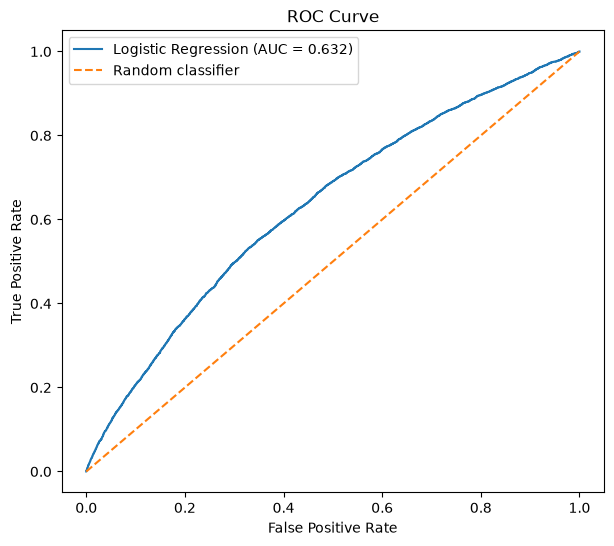

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [92]:
import numpy as np

X = np.array([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4]
])

y = np.array([0, 0, 1, 1])

beta = np.zeros(X.shape[1])

z = X @ beta
p = 1 / (1 + np.exp(-z))

gradient = (X.T @ (p - y)) / len(y)

learning_rate = 0.1

beta_new = beta - learning_rate * gradient

print("z =", z)
print("p =", p)
print("gradient =", gradient)
print("beta_new =", beta_new)

z = [0. 0. 0. 0.]
p = [0.5 0.5 0.5 0.5]
gradient = [ 0.  -0.5]
beta_new = [0.   0.05]


In [93]:
z = X @ beta
p = 1 / (1 + np.exp(-z))

gradient = (X.T @ (p - y)) / len(y)

beta_new = beta - learning_rate * gradient

print("z =", z)
print("p =", p)
print("gradient =", gradient)
print("beta_new =", beta_new)

z = [0. 0. 0. 0.]
p = [0.5 0.5 0.5 0.5]
gradient = [ 0.  -0.5]
beta_new = [0.   0.05]


#### Step 1 — Make the logistic regression configuration explicit

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]


# is this a correct transformation for all the numerical features? Can you do something else?
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # think what else you can do
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(              # one-hot
                                            # you can also use the ordinal encoding 
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ))
])

In [99]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',...,'CODE_GENDER', 'FLAG_OWN_CAR','FLAG_OWN_REALTY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

#### Step 2 — Look inside the optimizer

In [ ]:
classifier = model.named_steps["classifier"]

print("Solver:", classifier.solver)
print("Iterations:", classifier.n_iter_)
print("Intercept:", classifier.intercept_)
print("Number of coefficients:", classifier.coef_.shape)

Solver: lbfgs
Iterations: [26]
Intercept: [-2.53641331]
Number of coefficients: (1, 13)


#### Step 3 — Let's examine the learned coefficients

In [101]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = classifier.coef_[0]

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature:40s} {coef: .4f}")

num__AMT_INCOME_TOTAL                    -0.0087
num__AMT_CREDIT                           1.1168
num__AMT_ANNUITY                          0.0864
num__AMT_GOODS_PRICE                     -1.3327
num__DAYS_BIRTH                           0.2790
num__DAYS_EMPLOYED                       -0.0150
num__CNT_CHILDREN                         0.0454
num__CNT_FAM_MEMBERS                     -0.0580
cat__NAME_CONTRACT_TYPE_Revolving loans  -0.4523
cat__CODE_GENDER_M                        0.4324
cat__CODE_GENDER_XNA                     -0.0007
cat__FLAG_OWN_CAR_Y                      -0.3516
cat__FLAG_OWN_REALTY_Y                    0.0370


#### Step 4 — Before changing anything, establish our baseline

In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = model.predict(X_val)

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1       :", f1_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))
print("PR-AUC   :", average_precision_score(y_val, y_val_proba))

Accuracy : 0.9192722306228964
Precision: 0.0
Recall   : 0.0
F1       : 0.0
ROC-AUC  : 0.6318275044060413
PR-AUC   : 0.13012399761864804


/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Which regularization should we use?

For this problem, I would start with L2 regularization, then compare it against L1.

| Regularization | What it does                         | Usefulness here              |
| -------------- | ------------------------------------ | ---------------------------- |
| **L2 (Ridge)** | Shrinks coefficients toward 0        | **Start here**               |
| **L1 (Lasso)** | Can shrink coefficients exactly to 0 | Useful for feature selection |
| Elastic Net    | Combination of L1 + L2               | Later experiment             |


What does regularization do?

With L2 regularization, we add a penalty for large coefficients.

Instead of minimizing only:

$$ \text{Loss} $$

we minimize:

$$ \boxed{ J(\beta) = \text{Logistic Loss} + \lambda \sum_{j=1}^{p}\beta_j^2 } $$

where 
$\lambda$
is the penalty strength.

So now the model has two competing objectives:

Objective 1 — Fit the data

Make logistic loss small.

Objective 2 — Keep coefficients small

Make:

$$ \sum_j \beta_j^2 $$

small.

Therefore:

Regularization tells the model: "Fit the data, but don't use unnecessarily large coefficients."

In [103]:
# let's manually run a few experiments so you can see what regularization does.
C_values = [0.01, 0.1, 1, 10, 100]

results = []

for C in C_values:

    classifier = LogisticRegression(
        solver="lbfgs",
        C=C,
        max_iter=1000
    )

    experiment_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    experiment_model.fit(X_train, y_train)

    proba = experiment_model.predict_proba(X_val)[:, 1]

    results.append({
        "C": C,
        "ROC_AUC": roc_auc_score(y_val, proba),
        "PR_AUC": average_precision_score(y_val, proba)
    })

results

[{'C': 0.01, 'ROC_AUC': 0.6302471789775947, 'PR_AUC': 0.1284503117441835},
 {'C': 0.1, 'ROC_AUC': 0.6317659642827893, 'PR_AUC': 0.1300279215656583},
 {'C': 1, 'ROC_AUC': 0.6318275044060413, 'PR_AUC': 0.13012399761864804},
 {'C': 10, 'ROC_AUC': 0.6318362749868485, 'PR_AUC': 0.1301260938008986},
 {'C': 100, 'ROC_AUC': 0.6318371228334091, 'PR_AUC': 0.13012769049070727}]

In [104]:
# Run the coefficient inspection first, followed by the C_Value experiment
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature:40s} {coef: .4f}")

num__AMT_INCOME_TOTAL                    -0.0087
num__AMT_CREDIT                           1.1168
num__AMT_ANNUITY                          0.0864
num__AMT_GOODS_PRICE                     -1.3327
num__DAYS_BIRTH                           0.2790
num__DAYS_EMPLOYED                       -0.0150
num__CNT_CHILDREN                         0.0454
num__CNT_FAM_MEMBERS                     -0.0580
cat__NAME_CONTRACT_TYPE_Revolving loans  -0.4523
cat__CODE_GENDER_M                        0.4324
cat__CODE_GENDER_XNA                     -0.0007
cat__FLAG_OWN_CAR_Y                      -0.3516
cat__FLAG_OWN_REALTY_Y                    0.0370


In [105]:
# before throwing more features into the model, let's examine multicollinearity in our actual modeling features.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = X_train[numeric_features].copy()

X_num = X_num.fillna(X_num.median())

X_num_scaled = StandardScaler().fit_transform(X_num)

vif = pd.DataFrame({
    "Feature": numeric_features,
    "VIF": [
        variance_inflation_factor(X_num_scaled, i)
        for i in range(X_num_scaled.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Feature,VIF
3,AMT_GOODS_PRICE,38.921426
1,AMT_CREDIT,38.220095
6,CNT_CHILDREN,4.603810
7,CNT_FAM_MEMBERS,4.484924
2,AMT_ANNUITY,2.557314
4,DAYS_BIRTH,1.740059
5,DAYS_EMPLOYED,1.649342
0,AMT_INCOME_TOTAL,1.033906


#### Should we remove AMT_GOODS_PRICE
#### Maybe, but can we represent the underlying financial relationship more meaningfully?

In [107]:
# Let's see the description
desc_df = pd.read_csv('../data/raw/credit_default_data/HomeCredit_columns_description.csv', encoding='cp1252')

In [110]:
desc_df.head(20)

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


Think about the business problem

We are predicting:

$$ P(\text{default}=1) $$

A raw variable such as:

AMT_CREDIT = ₹500,000

doesn't tell us the whole story.

₹500,000 of credit means something very different for:

Income = ₹100,000

versus:

Income = ₹1,000,000

This suggests a ratio:

$$ \boxed{ \text{CREDIT\_INCOME\_RATIO} = \frac{AMT\_CREDIT}{AMT\_INCOME\_TOTAL} } $$

Similarly:

$$ \boxed{ \text{ANNUITY\_INCOME\_RATIO} = \frac{AMT\_ANNUITY}{AMT\_INCOME\_TOTAL} } $$

And because AMT_GOODS_PRICE and AMT_CREDIT are strongly related:

$$ \boxed{ \text{CREDIT\_GOODS\_RATIO} = \frac{AMT\_CREDIT}{AMT\_GOODS\_PRICE} } $$

These features can potentially capture the financial burden more directly than the raw variables.

In [111]:
# Let's create the first three engineering features
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["CREDIT_GOODS_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
)

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/3970158481.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_INCOME_RATIO"] = (
/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/3970158481.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_INCOME_RATIO"] = (
/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/3970158481.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor p

In [112]:
df[
    [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_GOODS_RATIO"
    ]
].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO
count,307511.000000,307499.000000,307233.000000
mean,3.957570,0.180930,1.122995
std,2.689728,0.094574,0.124045
min,0.004808,0.000224,0.150000
25%,2.018667,0.114782,1.000000
50%,3.265067,0.162833,1.118800
75%,5.159880,0.229067,1.198000
max,84.736842,1.875965,6.000000


In [113]:
# let's check whether the engineered features actually contain predictive information
df.groupby(
    pd.qcut(df["CREDIT_INCOME_RATIO"], 10, duplicates="drop")
)["TARGET"].mean()

CREDIT_INCOME_RATIO
(0.00381, 1.332]    0.069085
(1.332, 1.818]      0.077615
(1.818, 2.266]      0.081126
(2.266, 2.764]      0.090212
(2.764, 3.265]      0.086542
(3.265, 3.906]      0.091962
(3.906, 4.725]      0.086168
(4.725, 5.769]      0.079510
(5.769, 7.488]      0.074412
(7.488, 84.737]     0.070656
Name: TARGET, dtype: float64

#### maybe try the outlier detection

In [114]:
df.groupby(
    pd.qcut(df["ANNUITY_INCOME_RATIO"], 10, duplicates="drop")
)["TARGET"].mean()

ANNUITY_INCOME_RATIO
(-0.000776, 0.08]    0.071354
(0.08, 0.104]        0.072618
(0.104, 0.125]       0.078194
(0.125, 0.144]       0.078439
(0.144, 0.163]       0.078779
(0.163, 0.186]       0.083743
(0.186, 0.212]       0.085381
(0.212, 0.247]       0.088541
(0.247, 0.302]       0.088394
(0.302, 1.876]       0.081919
Name: TARGET, dtype: float64

In [115]:
df.groupby(
    pd.qcut(df["CREDIT_GOODS_RATIO"], 10, duplicates="drop")
)["TARGET"].mean()

CREDIT_GOODS_RATIO
(0.149, 1.0]      0.067466
(1.0, 1.079]      0.047491
(1.079, 1.119]    0.067767
(1.119, 1.145]    0.067435
(1.145, 1.168]    0.088091
(1.168, 1.211]    0.100472
(1.211, 1.277]    0.099110
(1.277, 6.0]      0.127406
Name: TARGET, dtype: float64

#### Let's build Model B

In [116]:
numeric_features_v2 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]

categorical_features_v2 = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

In [117]:
features_v2 = numeric_features_v2 + categorical_features_v2

X = df[features_v2]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [118]:
numeric_transformer_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_v2 = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor_v2 = ColumnTransformer([
    ("num", numeric_transformer_v2, numeric_features_v2),
    ("cat", categorical_transformer_v2, categorical_features_v2)
])

In [119]:
model_v2 = Pipeline([
    ("preprocessor", preprocessor_v2),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        C=1,
        max_iter=1000
    ))
])

In [120]:
model_v2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',...,'CODE_GENDER', 'FLAG_OWN_CAR','FLAG_OWN_REALTY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [121]:
y_val_proba_v2 = model_v2.predict_proba(X_val)[:, 1]

roc_auc_v2 = roc_auc_score(
    y_val,
    y_val_proba_v2
)

pr_auc_v2 = average_precision_score(
    y_val,
    y_val_proba_v2
)

print("ROC-AUC:", roc_auc_v2)
print("PR-AUC :", pr_auc_v2)

ROC-AUC: 0.6337637686451879
PR-AUC : 0.13425215249189043


Let's do feature ablation

We'll train four models:

Model A

Original features.

Model B

Original + CREDIT_INCOME_RATIO

Model C

Original + ANNUITY_INCOME_RATIO

Model D

Original + CREDIT_GOODS_RATIO

Model E

Original + all three.

In [122]:
ratio_sets = {
    "baseline": [],
    "credit_income": ["CREDIT_INCOME_RATIO"],
    "annuity_income": ["ANNUITY_INCOME_RATIO"],
    "credit_goods": ["CREDIT_GOODS_RATIO"],
    "all_ratios": [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_GOODS_RATIO"
    ]
}

base_numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

ablation_results = []

for name, ratios in ratio_sets.items():

    numeric_features = base_numeric_features + ratios

    features = numeric_features + categorical_features

    X = df[features]
    y = df["TARGET"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="lbfgs",
            C=1,
            max_iter=1000
        ))
    ])

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_val)[:, 1]

    ablation_results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_val, proba),
        "PR_AUC": average_precision_score(y_val, proba)
    })

pd.DataFrame(ablation_results)

,Model,ROC_AUC,PR_AUC
0,baseline,0.631828,0.130124
1,credit_income,0.633141,0.131663
2,annuity_income,0.632584,0.132201
3,credit_goods,0.632959,0.132016
4,all_ratios,0.633764,0.134252


                    Applicant
                       │
          ┌────────────┼────────────┐
          ↓            ↓            ↓
    Credit/Income  Annuity/Income  Credit/Goods
          │            │            │
          ↓            ↓            ↓
     borrowing       payment      financing
       burden         burden       structure
          │            │            │
          └────────────┼────────────┘
                       ↓
                 Logistic Model
                       ↓
                Default probability

In [ ]:
# Let's address our multicolinearity problem
''' 
Can we replace some redundant raw information with a more meaningful representation without 
losing predictive performance?
'''
numeric_features_v3 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    # "AMT_GOODS_PRICE",  <-- I'm removing this
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]

categorical_features_v2 = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor_v3 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_v3),
    ("cat", categorical_transformer, categorical_features_v2)
])

model_v3 = Pipeline([
    ("preprocessor", preprocessor_v3),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        C=1,
        max_iter=1000
    ))
])

In [124]:
features_v3 = numeric_features_v3 + categorical_features_v2

X = df[features_v3]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [125]:
model_v3.fit(X_train, y_train)

y_val_proba_v3 = model_v3.predict_proba(X_val)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_v3)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_proba_v3)
)

ROC-AUC: 0.6328904831254132
PR-AUC: 0.13378523366661052


In [127]:
numeric_features_v2

['AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'CREDIT_INCOME_RATIO',
 'ANNUITY_INCOME_RATIO',
 'CREDIT_GOODS_RATIO']

In [128]:
# Let's verify the VIF
numeric_features_v2 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]

categorical_features_v2 = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]
features_v2 = numeric_features_v2 + categorical_features_v2
X = df[features_v2]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_num = X_train[numeric_features_v2].copy()

X_num = X_num.fillna(X_num.median())

X_num_scaled = StandardScaler().fit_transform(X_num)

vif_v2 = pd.DataFrame({
    "Feature": numeric_features_v2,
    "VIF": [
        variance_inflation_factor(
            X_num_scaled,
            i
        )
        for i in range(X_num_scaled.shape[1])
    ]
})

vif_v2.sort_values("VIF", ascending=False)

,Feature,VIF
1,AMT_CREDIT,122.902265
3,AMT_GOODS_PRICE,116.437963
8,CREDIT_INCOME_RATIO,12.325647
9,ANNUITY_INCOME_RATIO,8.932882
2,AMT_ANNUITY,8.042398
6,CNT_CHILDREN,4.622488
7,CNT_FAM_MEMBERS,4.518035
10,CREDIT_GOODS_RATIO,3.041955
4,DAYS_BIRTH,1.740742
5,DAYS_EMPLOYED,1.673468


Think about CREDIT_GOODS_RATIO

We created:

$$ R=\frac{C}{G} $$

where:

$$ C=AMT\_CREDIT $$

and:

$$ G=AMT\_GOODS\_PRICE $$

Now our model contains all three:

$$ C,\quad G,\quad \frac{C}{G} $$

These are obviously not independent pieces of information.

In [132]:
# Let's remove the multicolinearity
numeric_features_v4 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]
categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]
features_v4 = numeric_features_v4 + categorical_features_v2

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor_v4 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_v4),
    ("cat", categorical_transformer, categorical_features_v2)
])

model_v4 = Pipeline([
    ("preprocessor", preprocessor_v4),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        C=1,
        max_iter=1000
    ))
])

In [133]:
features_v4 = numeric_features_v4 + categorical_features_v2

X = df[features_v4]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [135]:
model_v4.fit(X_train, y_train)

y_val_proba_v4 = model_v4.predict_proba(X_val)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_v4)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_proba_v4)
)

ROC-AUC: 0.6415262420800711
PR-AUC: 0.13857378719349356


In [136]:
# Let's check VIF again
numeric_features_v4 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO"
]

X_num = X_train[numeric_features_v4].copy()

X_num = X_num.fillna(X_num.median())

X_num_scaled = StandardScaler().fit_transform(X_num)

vif_v4 = pd.DataFrame({
    "Feature": numeric_features_v4,
    "VIF": [
        variance_inflation_factor(
            X_num_scaled,
            i
        )
        for i in range(X_num_scaled.shape[1])
    ]
})

vif_v4.sort_values("VIF", ascending=False)

,Feature,VIF
4,CNT_CHILDREN,4.615586
6,CREDIT_INCOME_RATIO,4.537840
5,CNT_FAM_MEMBERS,4.502146
7,ANNUITY_INCOME_RATIO,2.938865
1,AMT_CREDIT,2.070969
2,DAYS_BIRTH,1.182969
0,AMT_INCOME_TOTAL,1.094107
3,DAYS_EMPLOYED,1.047716
8,CREDIT_GOODS_RATIO,1.019015


DAYS_EMPLOYED = 365243

Appears roughly for 18%

In [130]:
df["DAYS_EMPLOYED_ANOMALY"] = (
    df["DAYS_EMPLOYED"] == 365243
).astype(int)

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/3117317078.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAYS_EMPLOYED_ANOMALY"] = (


In [131]:
# replace the sentinel
df.loc[
    df["DAYS_EMPLOYED"] == 365243,
    "DAYS_EMPLOYED"
] = np.nan

#### Let's create the model again

In [137]:
numeric_features_v5 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "DAYS_EMPLOYED_ANOMALY"
]
categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]
features_v5 = numeric_features_v5 + categorical_features_v2

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor_v5 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_v5),
    ("cat", categorical_transformer, categorical_features_v2)
])

model_v5 = Pipeline([
    ("preprocessor", preprocessor_v5),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        C=1,
        max_iter=1000
    ))
])

In [138]:
features_v5 = numeric_features_v5 + categorical_features_v2

X = df[features_v5]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [139]:
model_v5.fit(X_train, y_train)

y_val_proba_v5 = model_v5.predict_proba(X_val)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_v5)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_proba_v5)
)

ROC-AUC: 0.6428314555491326
PR-AUC: 0.13973669900800617


#### Let's inspect what the model actually learned
Convert coefficients into odds ratios

This makes logistic regression much easier to interpret.

The odds ratio is:

$$ OR=e^\beta $$

In [143]:
coefficients = model_v5.named_steps["classifier"].coef_[0]

feature_names = (
    model_v5.named_steps["preprocessor"]
    .get_feature_names_out()
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_df.sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient,odds_ratio
11,cat__CODE_GENDER_M,0.442542,1.556660
3,num__DAYS_EMPLOYED,0.232675,1.261972
8,num__CREDIT_GOODS_RATIO,0.202310,1.224228
2,num__DAYS_BIRTH,0.195645,1.216095
7,num__ANNUITY_INCOME_RATIO,0.144089,1.154987
4,num__CNT_CHILDREN,0.061378,1.063301
14,cat__FLAG_OWN_REALTY_Y,0.039933,1.040741
0,num__AMT_INCOME_TOTAL,0.014644,1.014752
6,num__CREDIT_INCOME_RATIO,0.000316,1.000316
12,cat__CODE_GENDER_XNA,-0.000185,0.999815


In [144]:
coef_df.sort_values(
    "coefficient",
    ascending=False
).head(10)

,feature,coefficient,odds_ratio
11,cat__CODE_GENDER_M,0.442542,1.556660
3,num__DAYS_EMPLOYED,0.232675,1.261972
8,num__CREDIT_GOODS_RATIO,0.202310,1.224228
2,num__DAYS_BIRTH,0.195645,1.216095
7,num__ANNUITY_INCOME_RATIO,0.144089,1.154987
4,num__CNT_CHILDREN,0.061378,1.063301
14,cat__FLAG_OWN_REALTY_Y,0.039933,1.040741
0,num__AMT_INCOME_TOTAL,0.014644,1.014752
6,num__CREDIT_INCOME_RATIO,0.000316,1.000316
12,cat__CODE_GENDER_XNA,-0.000185,0.999815


In [146]:
coef_df.sort_values(
    "coefficient",
    ascending=True
).head(10)

,feature,coefficient,odds_ratio
13,cat__FLAG_OWN_CAR_Y,-0.320107,0.726071
10,cat__NAME_CONTRACT_TYPE_Revolving loans,-0.288429,0.749440
1,num__AMT_CREDIT,-0.156650,0.855003
9,num__DAYS_EMPLOYED_ANOMALY,-0.103160,0.901983
5,num__CNT_FAM_MEMBERS,-0.073311,0.929312
12,cat__CODE_GENDER_XNA,-0.000185,0.999815
6,num__CREDIT_INCOME_RATIO,0.000316,1.000316
0,num__AMT_INCOME_TOTAL,0.014644,1.014752
14,cat__FLAG_OWN_REALTY_Y,0.039933,1.040741
4,num__CNT_CHILDREN,0.061378,1.063301


#### Let's see logistic regression from scratch using batch gradient descent.
Initial β

>   ↓

z = Xβ

>   ↓

p = sigmoid(z)

>   ↓

Calculate log-loss

>   ↓

Calculate gradient

>   ↓

Update β

>   ↓

Repeat

$$z=Xβ$$
$$ p=\sigma(z)=\frac{1}{1+e^{-z}} $$ $$ J(\beta) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i\log(p_i)+(1-y_i)\log(1-p_i) \right] $$

and

$$ \nabla J(\beta)=\frac{1}{n}X^T(p-y) $$

Then gradient descent updates:

$$ \boxed{\beta_{\text{new}}=\beta-\alpha\nabla J(\beta)} $$

where \(\alpha\) is the learning rate.

In [ ]:
# Let's see this with a simple dataset
import numpy as np

X = np.array([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4]
])
# first column represents the intercept [1,1]

y = np.array([0, 0, 1, 1])

In [148]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [149]:
z = np.array([-2, -1, 0, 1, 2])

print(sigmoid(z))

[0.11920292 0.26894142 0.5        0.73105858 0.88079708]


In [156]:
# Loss function
def log_loss(y, p):
    epsilon = 1e-15

    p = np.clip(p, epsilon, 1 - epsilon)        #clip is to prevent the log(0)

    return -np.mean(
        y * np.log(p) +
        (1 - y) * np.log(1 - p)
    )

In [151]:
r = 2
for i in range(10):
    r = r/2
    r = np.clip(r, 0.1, 2)
    print(r)

1.0
0.5
0.25
0.125
0.1
0.1
0.1
0.1
0.1
0.1


In [152]:
# implement one gradient step
beta = np.zeros(X.shape[1])

print(beta)

[0. 0.]


In [153]:
z = X @ beta
p = sigmoid(z)

gradient = (X.T @ (p - y)) / len(y)

print("z:", z)
print("p:", p)
print("gradient:", gradient)

z: [0. 0. 0. 0.]
p: [0.5 0.5 0.5 0.5]
gradient: [ 0.  -0.5]


In [154]:
# update
learning_rate = 0.1

beta = beta - learning_rate * gradient

print(beta)

[0.   0.05]


In [157]:
# let's automate the whole process
beta = np.zeros(X.shape[1])

learning_rate = 0.1
n_iterations = 1000

loss_history = []

for i in range(n_iterations):

    # 1. Linear prediction
    z = X @ beta

    # 2. Convert to probability
    p = sigmoid(z)

    # 3. Calculate loss
    loss = log_loss(y, p)
    loss_history.append(loss)

    # 4. Calculate gradient
    gradient = (X.T @ (p - y)) / len(y)

    # 5. Update coefficients
    beta = beta - learning_rate * gradient

print("Final beta:", beta)
print("Final loss:", loss_history[-1])

Final beta: [-5.6964092   2.38668654]
Final loss: 0.14999294932652518


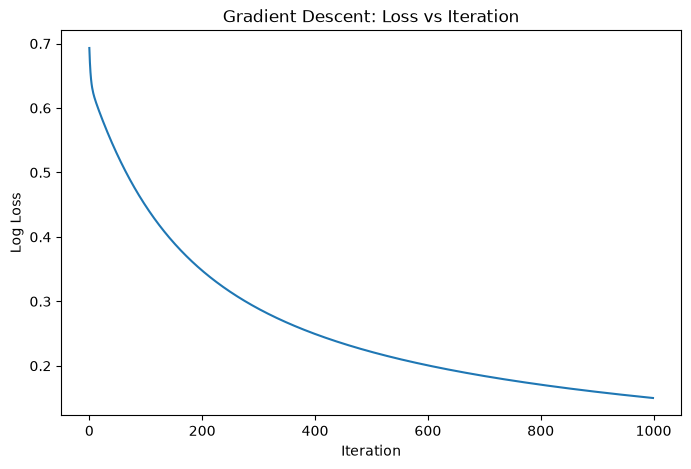

In [158]:
# Let's plot the optimization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Gradient Descent: Loss vs Iteration")

plt.show()

In [160]:
# Let's see the transformed matrices from the existing pipeline
preprocessor = model_v5.named_steps["preprocessor"]

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(X_train_processed.shape)
print(X_val_processed.shape)
print(type(X_train_processed))

(246008, 15)
(61503, 15)
<class 'numpy.ndarray'>


Understand what we're optimizing

Our transformed training matrix is:

$$ X \in \mathbb{R}^{246008\times15} $$

and:

$$ y \in \mathbb{R}^{246008} $$

Our coefficient vector will therefore be:

$$ \beta \in \mathbb{R}^{15} $$

We need one coefficient for every transformed feature.

In [161]:
# initialise weights w
beta = np.zeros(X_train_processed.shape[1])

print(beta.shape)
print(beta)

(15,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [162]:
# let's calculate the initial prediction
z = X_train_processed @ beta

p = sigmoid(z)

print("z shape:", z.shape)
print("p shape:", p.shape)
print("First 10 probabilities:")
print(p[:10])

z shape: (246008,)
p shape: (246008,)
First 10 probabilities:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [163]:
# The inital loss
loss = log_loss(y_train, p)

print("Initial loss:", loss)

Initial loss: 0.6931471805599453


In [164]:
# Calculate the gradient
gradient = (
    X_train_processed.T @ (p - y_train)
) / len(y_train)

print("Gradient shape:", gradient.shape)
print("Gradient:")
print(gradient)

Gradient shape: (15,)
Gradient:
[ 7.42886686e-04  8.39137498e-03 -2.16483190e-02 -1.73099256e-02
 -5.54293375e-03 -2.67101398e-03  2.02810080e-03 -4.21197037e-03
 -1.85721810e-02  1.26446280e-02  4.24213847e-02  1.36310608e-01
  4.06490846e-06  1.45184303e-01  2.91636857e-01]


In [165]:
# one gradient update
learning_rate = 0.01

beta_new = beta - learning_rate * gradient

print(beta_new)

[-7.42886686e-06 -8.39137498e-05  2.16483190e-04  1.73099256e-04
  5.54293375e-05  2.67101398e-05 -2.02810080e-05  4.21197037e-05
  1.85721810e-04 -1.26446280e-04 -4.24213847e-04 -1.36310608e-03
 -4.06490846e-08 -1.45184303e-03 -2.91636857e-03]


In [166]:
# Let's automate
beta = np.zeros(X_train_processed.shape[1])

learning_rate = 0.01
n_iterations = 100

loss_history = []

for i in range(n_iterations):

    # Forward pass
    z = X_train_processed @ beta
    p = sigmoid(z)

    # Loss
    loss = log_loss(y_train, p)
    loss_history.append(loss)

    # Gradient
    gradient = (
        X_train_processed.T @ (p - y_train)
    ) / len(y_train)

    # Parameter update
    beta = beta - learning_rate * gradient

    if i % 10 == 0:
        print(
            f"Iteration {i}: "
            f"Loss = {loss:.6f}"
        )

Iteration 0: Loss = 0.693147
Iteration 10: Loss = 0.680643
Iteration 20: Loss = 0.668723
Iteration 30: Loss = 0.657360
Iteration 40: Loss = 0.646526
Iteration 50: Loss = 0.636194
Iteration 60: Loss = 0.626341
Iteration 70: Loss = 0.616940
Iteration 80: Loss = 0.607969
Iteration 90: Loss = 0.599406


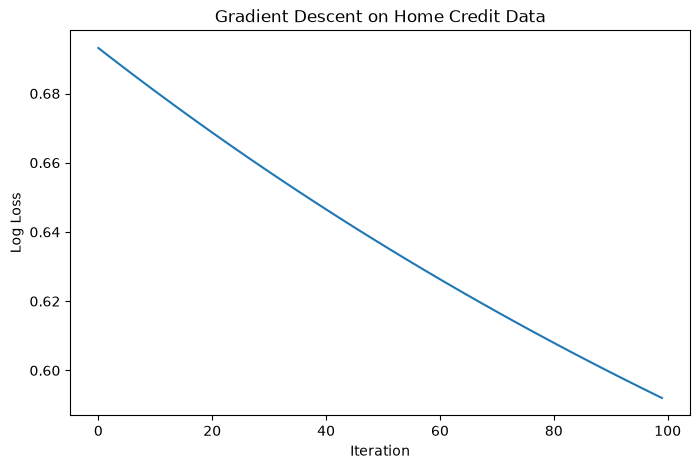

In [167]:
# Let's plot the optimization
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Gradient Descent on Home Credit Data")

plt.show()

In [170]:
# Let's add more features
import numpy as np

# Age in years
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

# Employment duration in years
# DAYS_EMPLOYED has already had 365243 replaced with NaN
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365.25

# Nonlinear age effect
df["AGE_SQUARED"] = df["AGE_YEARS"] ** 2

# Log transformations of highly skewed financial variables
df["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])
df["LOG_CREDIT"] = np.log1p(df["AMT_CREDIT"])


/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_21764/2097881071.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_SQUARED"] = df["AGE_YEARS"] ** 2


In [171]:
df[
    [
        "AGE_YEARS",
        "EMPLOYMENT_YEARS",
        "AGE_SQUARED",
        "LOG_INCOME",
        "LOG_CREDIT"
    ]
].describe()

,AGE_YEARS,EMPLOYMENT_YEARS,AGE_SQUARED,LOG_INCOME,LOG_CREDIT
count,307511.000000,252137.000000,307511.000000,307511.000000,307511.000000
mean,43.906900,6.527500,2070.568868,11.909245,13.070108
std,11.947950,6.402081,1074.633512,0.488906,0.715193
min,20.503765,-0.000000,420.404361,10.152338,10.714440
25%,33.984942,2.099932,1154.976271,11.630717,12.506181
50%,43.121150,4.511978,1859.433568,11.899215,13.149068
75%,53.886379,8.692676,2903.741862,12.218500,13.603123
max,69.073238,49.040383,4771.112140,18.577685,15.214228


In [172]:
numeric_features_v6 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",

    "DAYS_BIRTH",
    "DAYS_EMPLOYED",

    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",

    "DAYS_EMPLOYED_ANOMALY",

    "AGE_SQUARED",
    "LOG_INCOME",
    "LOG_CREDIT"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

In [173]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor_v6 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_v6),
    ("cat", categorical_transformer, categorical_features)
])

In [174]:
model_v6 = Pipeline([
    ("preprocessor", preprocessor_v6),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [176]:
features_v6 = numeric_features_v6 + categorical_features

X = df[features_v6]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [177]:
model_v6.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['AMT_INCOME_TOTAL','AMT_CREDIT','DAYS_BIRTH',...,'CODE_GENDER', 'FLAG_OWN_CAR','FLAG_OWN_REALTY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [178]:
y_val_proba_v6 = model_v6.predict_proba(X_val)[:, 1]

In [179]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_v6 = roc_auc_score(
    y_val,
    y_val_proba_v6
)

pr_auc_v6 = average_precision_score(
    y_val,
    y_val_proba_v6
)

print("ROC-AUC:", roc_auc_v6)
print("PR-AUC :", pr_auc_v6)

ROC-AUC: 0.6457307559225378
PR-AUC : 0.14279318312781047


In [ ]:
# Let's try L2 regularization again
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

results = []

for C in C_values:

    model_v6 = Pipeline([
    ("preprocessor", preprocessor_v6),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=C,
        max_iter=1000,
        random_state=42
        ))
    ])

    model_v6.fit(X_train, y_train)

    y_proba = model_v6.predict_proba(X_val)[:, 1]

    results.append({
        "C": C,
        "ROC_AUC": roc_auc_score(y_val, y_proba),
        "PR_AUC": average_precision_score(y_val, y_proba)
    })

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [183]:
results

[{'C': 0.01, 'ROC_AUC': 0.6456753359689962, 'PR_AUC': 0.1426656170675131},
 {'C': 0.03, 'ROC_AUC': 0.6457180738479342, 'PR_AUC': 0.14275193373990205},
 {'C': 0.1, 'ROC_AUC': 0.6457269156763515, 'PR_AUC': 0.14278339116858715},
 {'C': 0.3, 'ROC_AUC': 0.645729035292753, 'PR_AUC': 0.14279115596469685},
 {'C': 1, 'ROC_AUC': 0.6457307559225378, 'PR_AUC': 0.14279318312781047},
 {'C': 3, 'ROC_AUC': 0.6457316180186203, 'PR_AUC': 0.14279335560366493},
 {'C': 10, 'ROC_AUC': 0.645731411400551, 'PR_AUC': 0.1427928835509236},
 {'C': 30, 'ROC_AUC': 0.6457312439686671, 'PR_AUC': 0.14279320629613798},
 {'C': 100, 'ROC_AUC': 0.6457311655962961, 'PR_AUC': 0.14279310800899134}]

In [185]:
# Let's try L1 regularization again
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

results = []

for C in C_values:

    model_v6 = Pipeline([
    ("preprocessor", preprocessor_v6),
    ("classifier", LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=1000,
        random_state=42
        ))
    ])

    model_v6.fit(X_train, y_train)

    y_proba = model_v6.predict_proba(X_val)[:, 1]

    results.append({
        "C": C,
        "ROC_AUC": roc_auc_score(y_val, y_proba),
        "PR_AUC": average_precision_score(y_val, y_proba)
    })
results

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

[{'C': 0.01, 'ROC_AUC': 0.646023124053097, 'PR_AUC': 0.14205745829594296},
 {'C': 0.03, 'ROC_AUC': 0.6460653631987642, 'PR_AUC': 0.14271315729672096},
 {'C': 0.1, 'ROC_AUC': 0.6459779851296975, 'PR_AUC': 0.14291197948551065},
 {'C': 0.3, 'ROC_AUC': 0.646001635773881, 'PR_AUC': 0.14313054576642134},
 {'C': 1, 'ROC_AUC': 0.6460002642573861, 'PR_AUC': 0.1432130139004822},
 {'C': 3, 'ROC_AUC': 0.6459970759268324, 'PR_AUC': 0.14321354246745865},
 {'C': 10, 'ROC_AUC': 0.6459974535391663, 'PR_AUC': 0.1432214155396226},
 {'C': 30, 'ROC_AUC': 0.6460077452564499, 'PR_AUC': 0.1432511816255044},
 {'C': 100, 'ROC_AUC': 0.6460147310846234, 'PR_AUC': 0.14325288521499227}]

K-folds Validation

With 5-fold stratified cross-validation, for example:

                 Training data
              ┌─────────────────┐
              │                 │
              │   Fold 1        │ → Validation
              │   Fold 2        │ → Validation
              │   Fold 3        │ → Validation
              │   Fold 4        │ → Validation
              │   Fold 5        │ → Validation
              │                 │
              └─────────────────┘

Iteration 1:  [VAL] [TRAIN] [TRAIN] [TRAIN] [TRAIN]

Iteration 2:  [TRAIN] [VAL] [TRAIN] [TRAIN] [TRAIN]

Iteration 3:  [TRAIN] [TRAIN] [VAL] [TRAIN] [TRAIN]

Iteration 4:  [TRAIN] [TRAIN] [TRAIN] [VAL] [TRAIN]

Iteration 5:  [TRAIN] [TRAIN] [TRAIN] [TRAIN] [VAL]

Because our target is imbalanced (~8% defaults), we should use StratifiedKFold, not ordinary KFold.

In [186]:
# Let's complete the pipeline with L2 regularization
model_v6 = Pipeline([
("preprocessor", preprocessor_v6),
("classifier", LogisticRegression(
    penalty="l2",
    C=C,
    max_iter=1000,
    random_state=42
    ))
])


In [187]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_v6,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=True
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [188]:
print("ROC-AUC:")
print(cv_results["test_roc_auc"])

print("\nPR-AUC:")
print(cv_results["test_pr_auc"])

ROC-AUC:
[0.65260947 0.6481731  0.65056312 0.6434568  0.64642986]

PR-AUC:
[0.14023698 0.13523291 0.14158645 0.1359626  0.13804541]


In [189]:
print(
    "Mean ROC-AUC:",
    cv_results["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    cv_results["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    cv_results["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    cv_results["test_pr_auc"].std()
)

Mean ROC-AUC: 0.6482464688479459
Std ROC-AUC: 0.003182734358726131
Mean PR-AUC: 0.1382128719083135
Std PR-AUC: 0.0024269313305939995


# Recommended next step
                    5-Fold Stratified CV
                             │
              ┌──────────────┴──────────────┐
              │                             │
             L2                            L1
              │                             │
          Tune C                        Tune C
              │                             │
              └──────────────┬──────────────┘
                             ↓
                    Compare mean ROC-AUC
                    Compare mean PR-AUC
                    Compare variability
                             ↓
                       Select model
                             ↓
                    Evaluate on X_val

# How should we start?
            Original application_train
                        │
                        ▼
                Stratified 90/10 split
                    /           \
                    /             \
            Development          Holdout
            90%                 10%
                │
                ▼
            5-fold CV
                │
                ├── L1/L2
                ├── C
                ├── features
                ├── transformations
                └── model selection
                        │
                        ▼
                    Freeze model
                        │
                        ▼
                Evaluate once
                on holdout

## How to handle the imbalanced dataset
Our class-imbalance laboratory

We have:

$$ P(Y=1)\approx 8.07\% $$

so:

TARGET = 0  ██████████████████████████████████████████████ 91.93%

TARGET = 1  ████                                           8.07%

Let's systematically test the following:

        Stratified sampling
        Class weighting
        Random oversampling
        Random undersampling
        SMOTE
        Threshold adjustment
        Eventually, calibration

And we'll distinguish between techniques that affect training and techniques that affect evaluation/decision making.

In [ ]:
# Experiment-1 Class Weighing
''' 
Does telling logistic regression:

"Pay more attention to defaults"

produce better ranking performance?
'''

numeric_features_v6 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",

    "DAYS_BIRTH",
    "DAYS_EMPLOYED",

    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",

    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",

    "DAYS_EMPLOYED_ANOMALY",

    "AGE_SQUARED",
    "LOG_INCOME",
    "LOG_CREDIT"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessor_v6 = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_v6),
    ("cat", categorical_transformer, categorical_features)
])

model_v6 = Pipeline([
("preprocessor", preprocessor_v6),
("classifier", LogisticRegression(
    penalty="l2",
    C=C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
    ))
])

features_v6 = numeric_features_v6 + categorical_features

X = df[features_v6]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_v6,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=True
)


/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [195]:
print(
    "Mean ROC-AUC:",
    cv_results["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    cv_results["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    cv_results["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    cv_results["test_pr_auc"].std()
)

Mean ROC-AUC: 0.6477980586939702
Std ROC-AUC: 0.003665825847222903
Mean PR-AUC: 0.13888074284381405
Std PR-AUC: 0.0027202216486204695


## Random oversampling

Now we actually change the training data.

Suppose a training fold contains:

        220,000 negative
        20,000 positive

We might oversample the positive class:

        220,000 negative
        220,000 positive

by repeatedly selecting minority observations.

Important:

        We only do this inside the training portion of each CV fold.

Never:

        Entire dataset
        ↓
        Oversample
        ↓
        CV
We need:

        Fold
        │
        ├── Training
        │      ↓
        │   Oversample
        │      ↓
        │   Fit model
        │
        └── Validation
                ↓
            untouched

In [ ]:
# uv add imbalanced-learn

In [196]:
# We need a different pipeline 
# because the pipeline needs to know that a resampling operation should happen during .fit()
# but not during .predict().
from imblearn.pipeline import Pipeline

In [203]:
# Create the oversampling pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

ros_model = Pipeline([
    ("preprocessor", preprocessor),
    ("oversampler", RandomOverSampler(
        sampling_strategy=0.25,         # we can change this ratio 1 means equal distribution
        random_state=42
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=1000,
        random_state=42
    ))
])

In [204]:
# Let's run the same 5-fold cross validation
from sklearn.model_selection import cross_validate

ros_cv_results = cross_validate(
    ros_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [205]:
print(
    "Mean ROC-AUC:",
    ros_cv_results["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    ros_cv_results["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    ros_cv_results["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    ros_cv_results["test_pr_auc"].std()
)

Mean ROC-AUC: 0.6445306298420325
Std ROC-AUC: 0.0032974771638791755
Mean PR-AUC: 0.13674012568023908
Std PR-AUC: 0.0025687278508300724


## Random Undersampling

In [206]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

In [211]:
rus_model = Pipeline([
    ("preprocessor", preprocessor),
    ("undersampler", RandomUnderSampler(
        sampling_strategy=0.25,
        random_state=42
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=100,
        max_iter=1000,
        random_state=42
    ))
])

In [212]:
rus_cv_results = cross_validate(
    rus_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [213]:
print(
    "Mean ROC-AUC:",
    rus_cv_results["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    rus_cv_results["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    rus_cv_results["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    rus_cv_results["test_pr_auc"].std()
)

Mean ROC-AUC: 0.6445954857579748
Std ROC-AUC: 0.0032018322129356382
Mean PR-AUC: 0.13676796339131828
Std PR-AUC: 0.002558842771309846


SMOTE = Synthetic Minority Over-sampling Technique.

Instead of simply duplicating minority observations like Random Oversampling, SMOTE creates new synthetic minority observations.

Suppose two defaulting customers have feature vectors:

$$ x_i $$

and

$$ x_j $$

SMOTE chooses a point between them:

$$ x_{\text{new}} = x_i+\lambda(x_j-x_i) $$

where

$$ 0\leq\lambda\leq1 $$

For example, if:

        Customer A: income = 100k, credit = 500k
        Customer B: income = 150k, credit = 600k

SMOTE might generate:

Synthetic: income = 125k, credit = 550k

| Method              | What happens?                                                            |
| ------------------- | ------------------------------------------------------------------------ |
| Random oversampling | Duplicate existing minority observations                                 |
| SMOTE               | Create synthetic minority observations                                   |
| Undersampling       | Remove majority observations                                             |
| Class weighting     | Keep all observations but give minority observations greater loss weight |


Ordinary SMOTE assumes that features are continuous/numerical.

If we one-hot encode:

CODE_GENDER_M

we get:

0 = Female
1 = Male

SMOTE could theoretically interpolate:

0 → 1

and produce:

0.37

That's not a valid gender category.

Therefore, SMOTENC is more appropriate for our current feature set.

|                SMOTE vs SMOTENC                       | SMOTE        | SMOTENC |
| -------------------------------------- | ------------ | ------- |
| Numerical variables                    | Yes          | Yes     |
| Categorical variables                  | Not directly | Yes     |
| One-hot encoding required              | Usually      | No      |
| Appropriate for our current mixed data | Not ideal    | **Yes** |


    Raw X
      │
      ├── Imputation
      │
      ↓
    SMOTENC
      │
      ├── synthetic numerical observations
      ├── synthetic categorical observations
      │
      ↓
    One-hot encoding
      ↓
    Scaling
      ↓
    Logistic Regression

In [214]:
# Let's try SMOTE on numerical data
smote_features = numeric_features_v6

X_smote = df[smote_features]
y_smote = df["TARGET"]

X_train_smote, X_val_smote, y_train_smote, y_val_smote = train_test_split(
    X_smote,
    y_smote,
    test_size=0.20,
    stratify=y_smote,
    random_state=42
)

In [215]:
# Put SMOTE under CV pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [216]:
smote_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(
        sampling_strategy=1.0,
        random_state=42
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=1000,
        random_state=42
    ))
])

In [217]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_smote = cross_validate(
    smote_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [218]:
print(
    "Mean ROC-AUC:",
    cv_results_smote["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    cv_results_smote["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    cv_results_smote["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    cv_results_smote["test_pr_auc"].std()
)

Mean ROC-AUC: 0.6350713441529829
Std ROC-AUC: 0.0026783979175111932
Mean PR-AUC: 0.12950908615424153
Std PR-AUC: 0.00197693757486231


In [219]:
# Let's do this properly on full feature set
numeric_features_v6 = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "DAYS_EMPLOYED_ANOMALY",
    "AGE_SQUARED",
    "LOG_INCOME",
    "LOG_CREDIT"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]




             Numeric             Categorical
                │                     │
                └──────────┬──────────┘
                           ↓
                       SMOTENC
                           ↓
                    synthetic minority
                           ↓
                    preprocessing
                           ↓
                  Logistic Regression

In [220]:
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [221]:
all_features = numeric_features_v6 + categorical_features

X = df[all_features].copy()
y = df["TARGET"]

In [ ]:
# Converting categorical columns into integer codes
for col in categorical_features:
    X[col] = X[col].astype("category").cat.codes

0         1
1         0
2         1
3         1
4         1
         ..
307506    0
307507    1
307508    1
307509    1
307510    0
Length: 307511, dtype: int8

In [223]:
# Split before SMOTENC
from sklearn.model_selection import train_test_split

X_train_smote, X_val_smote, y_train_smote, y_val_smote = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [224]:
categorical_indices = [
    all_features.index(col)
    for col in categorical_features
]

print(categorical_indices)

[13, 14, 15, 16]


In [225]:
# Building SMOTENC Pipleline
# Let's first impute the features separately
numeric_imputer = SimpleImputer(strategy="median")

categorical_imputer = SimpleImputer(strategy="most_frequent")

In [226]:
# Apply these to training data
X_train_smote[numeric_features_v6] = numeric_imputer.fit_transform(
    X_train_smote[numeric_features_v6]
)

X_train_smote[categorical_features] = categorical_imputer.fit_transform(
    X_train_smote[categorical_features]
)

X_val_smote[numeric_features_v6] = numeric_imputer.transform(
    X_val_smote[numeric_features_v6]
)

X_val_smote[categorical_features] = categorical_imputer.transform(
    X_val_smote[categorical_features]
)

In [234]:
smotenc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy=0.25,      # we can change this
    random_state=42
)

In [235]:
# Applying SMOTENC
X_train_resampled, y_train_resampled = smotenc.fit_resample(
    X_train_smote,
    y_train_smote
)

In [236]:
# Let's check the distribution
print("Before:")
print(y_train_smote.value_counts())

print("\nAfter:")
print(y_train_resampled.value_counts())

Before:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After:
TARGET
0    226148
1     56537
Name: count, dtype: int64


In [237]:
# Let's go ahead with the normal preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_v6
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

In [238]:
X_train_processed = preprocessor.fit_transform(
    X_train_resampled
)

X_val_processed = preprocessor.transform(
    X_val_smote
)

In [239]:
model = LogisticRegression(
    penalty="l2",
    C=100,
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_processed,
    y_train_resampled
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [240]:
# Evaluate

from sklearn.metrics import roc_auc_score, average_precision_score

y_val_proba = model.predict_proba(
    X_val_processed
)[:, 1]

roc_auc = roc_auc_score(
    y_val_smote,
    y_val_proba
)

pr_auc = average_precision_score(
    y_val_smote,
    y_val_proba
)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.637203931001392
PR-AUC: 0.13614155075904416


                Natural distribution
                        ↓
                0.6483
                        │
                        ├── Class weighting
                        │       0.6478
                        │
                        ├── Random oversampling
                        │       0.6446
                        │
                        ├── Random undersampling
                        │       0.6443
                        │
                        └── SMOTENC
                                0.6297

| Strategy                   |    ROC-AUC |     PR-AUC |
| -------------------------- | ---------: | ---------: |
| **Natural distribution**   | **0.6483** | **0.1382** |
| Class weighting            |     0.6478 | **0.1389** |
| Random oversampling — 50%  |     0.6446 |     0.1364 |
| Random undersampling — 50% |     0.6443 |     0.1363 |
| Random undersampling — 25% |     0.6446 |     0.1368 |
| SMOTE — numeric only, 50%  |     0.6351 |     0.1295 |
| SMOTENC — 50%              |     0.6297 |     0.1318 |
| **SMOTENC — 25%**          | **0.6372** | **0.1361** |


In [241]:
# Let's do 5-fold cross validation
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [242]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [245]:
# Natural Distribution
natural_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=100,
        max_iter=1000,
        random_state=42
    ))
])

In [246]:
# Weighting model
weighted_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=100,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [247]:
# Random oversampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

ros_model = Pipeline([
    ("preprocessor", preprocessor),
    ("oversampler", RandomOverSampler(
        sampling_strategy=1.0,
        random_state=42
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=100,
        max_iter=1000,
        random_state=42
    ))
])

In [248]:
# Random undersampling
from imblearn.under_sampling import RandomUnderSampler

rus_50_model = Pipeline([
    ("preprocessor", preprocessor),
    ("undersampler", RandomUnderSampler(
        sampling_strategy=1.0,
        random_state=42
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=100,
        max_iter=1000,
        random_state=42
    ))
])

In [249]:
# Random Undersampling at 0.25
rus_25_model = Pipeline([
    ("preprocessor", preprocessor),
    ("undersampler", RandomUnderSampler(
        sampling_strategy=0.25,
        random_state=42
    )),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=1000,
        random_state=42
    ))
])

In [250]:
def evaluate_model(name, model, X, y, cv):
    
    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision"
        },
        n_jobs=-1
    )
    
    print(f"\n{name}")
    print("-" * len(name))
    print(f"ROC-AUC: {results['test_roc_auc'].mean():.6f} "
          f"(± {results['test_roc_auc'].std():.6f})")
    print(f"PR-AUC:  {results['test_pr_auc'].mean():.6f} "
          f"(± {results['test_pr_auc'].std():.6f})")
    
    return results

In [251]:
natural_results = evaluate_model(
    "Natural distribution",
    natural_model,
    X_train,
    y_train,
    cv
)

weighted_results = evaluate_model(
    "Class weighting",
    weighted_model,
    X_train,
    y_train,
    cv
)

ros_results = evaluate_model(
    "Random oversampling 50%",
    ros_model,
    X_train,
    y_train,
    cv
)

rus50_results = evaluate_model(
    "Random undersampling 50%",
    rus_50_model,
    X_train,
    y_train,
    cv
)

rus25_results = evaluate_model(
    "Random undersampling 25%",
    rus_25_model,
    X_train,
    y_train,
    cv
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.


Natural distribution
--------------------
ROC-AUC: 0.647734 (± 0.003795)
PR-AUC:  0.139485 (± 0.002903)


/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.


Class weighting
---------------
ROC-AUC: 0.647798 (± 0.003666)
PR-AUC:  0.138881 (± 0.002720)


/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.


Random oversampling 50%
-----------------------
ROC-AUC: 0.647742 (± 0.003655)
PR-AUC:  0.138772 (± 0.002763)


/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.


Random undersampling 50%
------------------------
ROC-AUC: 0.647340 (± 0.003859)
PR-AUC:  0.138801 (± 0.003058)


/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.


Random undersampling 25%
------------------------
ROC-AUC: 0.647743 (± 0.003738)
PR-AUC:  0.139396 (± 0.002816)


#### Threshold Tuning

In [252]:
natural_model.fit(X_train, y_train)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](17,)","['AMT_INCOME_TOTAL','AMT_CREDIT','DAYS_BIRTH',...,'CODE_GENDER', 'FLAG_OWN_CAR','FLAG_OWN_REALTY']"
n_features_in_,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [ ]:
y_val_proba = natural_model.predict_proba(X_val)[:, 1]
# we are checking only for the defaulters

In [254]:
# Let's inspect the probabilities
pd.Series(y_val_proba).describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    6.150300e+04
mean     8.110184e-02
std      4.083827e-02
min      4.740171e-12
50%      7.268777e-02
75%      1.030671e-01
90%      1.361925e-01
95%      1.585812e-01
99%      2.061972e-01
max      9.942803e-01
dtype: float64

In [255]:
# Let's calculate the metrics at different threshold
from sklearn.metrics import confusion_matrix

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

for threshold in thresholds:
    
    y_pred = (y_val_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp)
    
    print(f"\nThreshold: {threshold:.2f}")
    print(f"TP: {tp:,}  FP: {fp:,}")
    print(f"TN: {tn:,}  FN: {fn:,}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")


Threshold: 0.05
TP: 4,375  FP: 42,912
TN: 13,642  FN: 574
Precision: 0.0925
Recall: 0.8840
Specificity: 0.2412

Threshold: 0.10
TP: 2,242  FP: 14,407
TN: 42,147  FN: 2,707
Precision: 0.1347
Recall: 0.4530
Specificity: 0.7453

Threshold: 0.15
TP: 746  FP: 3,322
TN: 53,232  FN: 4,203
Precision: 0.1834
Recall: 0.1507
Specificity: 0.9413

Threshold: 0.20
TP: 161  FP: 612
TN: 55,942  FN: 4,788
Precision: 0.2083
Recall: 0.0325
Specificity: 0.9892

Threshold: 0.25
TP: 25  FP: 81
TN: 56,473  FN: 4,924
Precision: 0.2358
Recall: 0.0051
Specificity: 0.9986

Threshold: 0.30
TP: 1  FP: 7
TN: 56,547  FN: 4,948
Precision: 0.1250
Recall: 0.0002
Specificity: 0.9999

Threshold: 0.40
TP: 0  FP: 3
TN: 56,551  FN: 4,949
Precision: 0.0000
Recall: 0.0000
Specificity: 0.9999

Threshold: 0.50
TP: 0  FP: 2
TN: 56,552  FN: 4,949
Precision: 0.0000
Recall: 0.0000
Specificity: 1.0000


F1 combines precision and recall:

$$ F_1= 2\frac{\text{Precision}\times\text{Recall}} {\text{Precision}+\text{Recall}} $$

In [256]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

for threshold in thresholds:
    
    y_pred = (y_val_proba >= threshold).astype(int)
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

Threshold=0.05 | Precision=0.0925 | Recall=0.8840 | F1=0.1675
Threshold=0.10 | Precision=0.1347 | Recall=0.4530 | F1=0.2076
Threshold=0.15 | Precision=0.1834 | Recall=0.1507 | F1=0.1655
Threshold=0.20 | Precision=0.2083 | Recall=0.0325 | F1=0.0563
Threshold=0.25 | Precision=0.2358 | Recall=0.0051 | F1=0.0099
Threshold=0.30 | Precision=0.1250 | Recall=0.0002 | F1=0.0004
Threshold=0.40 | Precision=0.0000 | Recall=0.0000 | F1=0.0000
Threshold=0.50 | Precision=0.0000 | Recall=0.0000 | F1=0.0000


#### Adding more features

In [257]:
ext_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

df[ext_features].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010


In [258]:
# Check for missingness

df[ext_features].isna().mean().sort_values(ascending=False)

EXT_SOURCE_1    0.563811
EXT_SOURCE_3    0.198253
EXT_SOURCE_2    0.002146
dtype: float64

In [259]:
df[ext_features + ["TARGET"]].corr()["TARGET"].sort_values()

EXT_SOURCE_3   -0.178919
EXT_SOURCE_2   -0.160472
EXT_SOURCE_1   -0.155317
TARGET          1.000000
Name: TARGET, dtype: float64

In [260]:
numeric_features_v7 = numeric_features_v6 + ext_features
numeric_features_v7 = list(dict.fromkeys(numeric_features_v7))  #removing the duplicates

In [261]:
preprocessor_v7 = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_v7
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features
        )
    ]
)

In [262]:
# new pipeline
model_v7 = Pipeline([
    ("preprocessor", preprocessor_v7),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        C=1,
        max_iter=1000,
        random_state=42
    ))
])

In [264]:
features_v7 = numeric_features_v7 + categorical_features_v2
X = df[features_v7]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_v7,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=True
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [265]:
cv_results

{'fit_time': array([0.74657702, 1.40472007, 1.39358425, 0.74117494, 1.26767707]),
 'score_time': array([0.060045  , 0.09363198, 0.10085702, 0.05832124, 0.094208  ]),
 'test_roc_auc': array([0.74199913, 0.74202796, 0.73514412, 0.73461971, 0.73378972]),
 'train_roc_auc': array([0.73693925, 0.73688705, 0.73858614, 0.73861976, 0.73904826]),
 'test_pr_auc': array([0.21665909, 0.21732491, 0.21873574, 0.21749292, 0.2083692 ]),
 'train_pr_auc': array([0.21523709, 0.21561581, 0.21514843, 0.21531915, 0.21755938])}

In [266]:
print(
    "Mean ROC-AUC:",
    cv_results["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    cv_results["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    cv_results["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    cv_results["test_pr_auc"].std()
)

Mean ROC-AUC: 0.7375161294644477
Std ROC-AUC: 0.0036974508686025186
Mean PR-AUC: 0.21571637248366132
Std PR-AUC: 0.003734429708519166


In [271]:
feature_sets = {
    "Current": numeric_features_v6,
    "Current + EXT1": numeric_features_v6 + ["EXT_SOURCE_1"],
    "Current + EXT2": numeric_features_v6 + ["EXT_SOURCE_2"],
    "Current + EXT3": numeric_features_v6 + ["EXT_SOURCE_3"],
    "Current + EXT1 + EXT2":
        numeric_features_v6 + ["EXT_SOURCE_1", "EXT_SOURCE_2"],
    "Current + EXT1 + EXT3":
        numeric_features_v6 + ["EXT_SOURCE_1", "EXT_SOURCE_3"],
    "Current + EXT2 + EXT3":
        numeric_features_v6 + ["EXT_SOURCE_2", "EXT_SOURCE_3"],
    "Current + All EXT":
        numeric_features_v6 + ext_features
}

In [275]:
results = []
for feat_name, num_feat in feature_sets.items():
    features_v7 = num_feat + categorical_features_v2
    preprocessor_v7 = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_feat
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features_v2
        )
    ]
    )
    X = df[features_v7]
    y = df["TARGET"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    model_v7 = Pipeline([
    ("preprocessor", preprocessor_v7),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        C=100,
        max_iter=1000,
        random_state=42
    ))
])

    cv_results = cross_validate(
        model_v7,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision"
        },
        n_jobs=-1,
        return_train_score=True
    )
    results.append((feat_name, {"Mean ROC-AUC":
    cv_results["test_roc_auc"].mean(), 
    "Mean PR-AUC":
    cv_results["test_pr_auc"].mean()}))
    
    

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [276]:
results

[('Current',
  {'Mean ROC-AUC': np.float64(0.6477340483339108),
   'Mean PR-AUC': np.float64(0.1394852600394317)}),
 ('Current + EXT1',
  {'Mean ROC-AUC': np.float64(0.6597731296352386),
   'Mean PR-AUC': np.float64(0.1440094216375976)}),
 ('Current + EXT2',
  {'Mean ROC-AUC': np.float64(0.6950603444439826),
   'Mean PR-AUC': np.float64(0.18162454288695581)}),
 ('Current + EXT3',
  {'Mean ROC-AUC': np.float64(0.7012721988030225),
   'Mean PR-AUC': np.float64(0.18007998299156042)}),
 ('Current + EXT1 + EXT2',
  {'Mean ROC-AUC': np.float64(0.7025540632124183),
   'Mean PR-AUC': np.float64(0.18356640874815006)}),
 ('Current + EXT1 + EXT3',
  {'Mean ROC-AUC': np.float64(0.7081742130257349),
   'Mean PR-AUC': np.float64(0.18369931074709056)}),
 ('Current + EXT2 + EXT3',
  {'Mean ROC-AUC': np.float64(0.7328353341005052),
   'Mean PR-AUC': np.float64(0.2132994940766529)}),
 ('Current + All EXT',
  {'Mean ROC-AUC': np.float64(0.7375173647016549),
   'Mean PR-AUC': np.float64(0.2157344105589044

In [277]:
# Let's add demographic categorical variables
demographic_features = [
    "NAME_TYPE_SUITE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE"
]

In [278]:
features_v8 = numeric_features_v7 + categorical_features_v2 + demographic_features


In [279]:
preprocessor_v8 = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_v7
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features_v2+demographic_features
        )
    ]
)

In [280]:
# new pipeline
model_v8 = Pipeline([
    ("preprocessor", preprocessor_v8),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        C=100,
        max_iter=1000,
        random_state=42
    ))
])

In [281]:
X = df[features_v8]
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_v8,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=True
)

/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/amitverma/Documents/GUVI/B-202/hands-on/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.

In [282]:
print(
    "Mean ROC-AUC:",
    cv_results["test_roc_auc"].mean()
)

print(
    "Std ROC-AUC:",
    cv_results["test_roc_auc"].std()
)

print(
    "Mean PR-AUC:",
    cv_results["test_pr_auc"].mean()
)

print(
    "Std PR-AUC:",
    cv_results["test_pr_auc"].std()
)

Mean ROC-AUC: 0.7419204873811777
Std ROC-AUC: 0.004092745348082781
Mean PR-AUC: 0.22007525311283221
Std PR-AUC: 0.004365268421816689
